## Task 4: Logging images, plots, and histograms

#### Goal: Use SummaryWriter to log images, matplotlib figures, and weight histograms.

1. Log an image (or a batch of images) using `writer.add_image()`. The image tensor must have shape `[C, H, W]` and values in `[0, 1]`. You can use a sample from a torchvision dataset or a randomly generated tensor.
2. Create a matplotlib figure (e.g. a plot of the loss curve or a scatter plot of predictions vs. targets) and log it using `writer.add_figure()`.
3. After each training epoch, log the weight distributions of the model's layers using `writer.add_histogram()` — iterate over `model.named_parameters()` and add a histogram for each parameter tensor.
4. Call `writer.flush()` after all logging calls and inspect the Images, Figures, and Histograms tabs in TensorBoard.

**Assignment:** Implement logging of images, matplotlib figures, and weight histograms using SummaryWriter. Verify that all three appear correctly in the corresponding TensorBoard tabs.


In [1]:
import torch

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [2]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter('runs/task_4')

In [10]:
import numpy as np

image = torch.rand(3, 28, 28)

writer.add_image('Random image', image, global_step=0)
writer.flush()
writer.close()

In [21]:
image.shape

torch.Size([3, 28, 28])

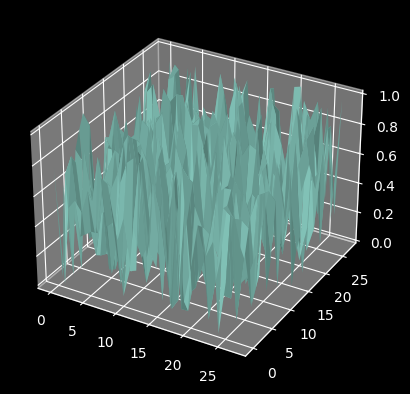

In [25]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

rand_values = image[0].numpy()
x, y = np.arange(28), np.arange(28)
X, Y = np.meshgrid(x, y)
ax.plot_surface(X, Y, rand_values)
plt.show(fig)

writer.add_figure('image as plot', fig, global_step=0)
writer.close()

In [26]:
import torch.nn as nn

model = nn.Sequential(nn.Linear(16, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(),nn.Linear(64, 7))

writer = SummaryWriter('runs/task_4/histograms')

for epoch in range(20):
    x = torch.rand(32, 16)
    y = torch.randint(0, 7, (32,))
    loss = nn.CrossEntropyLoss()(model(x), y)
    loss.backward()

    for name, param in model.named_parameters():
        writer.add_histogram(name, param, global_step=epoch)

    writer.flush()

writer.close()